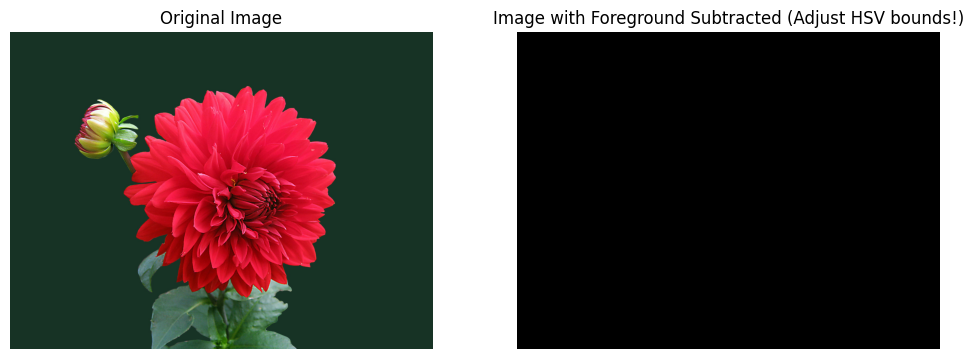

Foreground subtraction complete. Remember to adjust HSV bounds for optimal results.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def subtract_foreground_by_color(image_path, lower_hsv_bound, upper_hsv_bound):
    """
    Subtracts the foreground from an image based on a specified HSV color range.

    Args:
        image_path (str): The path to the input image.
        lower_hsv_bound (tuple): A tuple (H, S, V) representing the lower bound of the HSV color to subtract.
        upper_hsv_bound (tuple): A tuple (H, S, V) representing the upper bound of the HSV color to subtract.

    Returns:
        numpy.ndarray: The image with the specified color foreground removed (set to black),
                       or None if the image cannot be loaded.
    """
    # Read the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Convert BGR to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Create a mask for the specified foreground color range
    # Pixels within this range will be 255 (white), others 0 (black)
    mask = cv2.inRange(hsv, lower_hsv_bound, upper_hsv_bound)

    # Invert the mask to get everything *except* the foreground color
    # Now, pixels *not* in the foreground color range are 255 (white)
    mask_inv = cv2.bitwise_not(mask)

    # Use the inverted mask to extract the background (non-foreground) parts of the original image
    # This sets the foreground color regions to black
    result = cv2.bitwise_and(img, img, mask=mask_inv)

    return result

# --- Example Usage with 'image.jpg' ---

# 1. Define the path to your image
flower_image_path = 'image.jpg'

# 2. Define the HSV color range for the foreground you want to subtract.
# IMPORTANT: These values are placeholders. You will need to adjust them
# to accurately target the foreground color in 'image.jpg'.
# H values in OpenCV are 0-179, S and V are 0-255.
# Example: For a blue color (approx H=120), you might use:
# lower_hsv = np.array([110, 50, 50])
# upper_hsv = np.array([130, 255, 255])

# Placeholder values (adjust these for your specific image and foreground color)
lower_hsv_bound = np.array([0, 0, 0])      # Adjust these values
upper_hsv_bound = np.array([179, 255, 255]) # Adjust these values

# 3. Call the function to subtract the foreground
image_without_foreground = subtract_foreground_by_color(flower_image_path, lower_hsv_bound, upper_hsv_bound)

# 4. Display the results if successful
if image_without_foreground is not None:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(flower_image_path), cv2.COLOR_BGR2RGB)) # Original image
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(image_without_foreground, cv2.COLOR_BGR2RGB)) # Processed image
    plt.title('Image with Foreground Subtracted (Adjust HSV bounds!)')
    plt.axis('off')
    plt.show()

    print("Foreground subtraction complete. Remember to adjust HSV bounds for optimal results.")
else:
    print(f"Failed to process image: {flower_image_path}. Make sure the file exists.")